<a href="https://colab.research.google.com/github/jsak737/ML_LAB/blob/main/ML_Week_8_9_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 8 - AdaBoost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv("/content/income (1).csv")

le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

X = data.drop("income_level", axis=1)
y = data["income_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = AdaBoostClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy (10 estimators):", acc)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy (10 estimators): 0.8182004299314157
Confusion Matrix:
 [[6782  632]
 [1144 1211]]


In [ ]:
best_acc = 0
best_n = 0

for n in range(10, 201, 10):
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    if acc > best_acc:
        best_acc = acc
        best_n = n

print("Best Accuracy:", best_acc)
print("Best n_estimators:", best_n)

model = AdaBoostClassifier(n_estimators=best_n, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best Accuracy: 0.8334527587265841
Best n_estimators: 80
Confusion Matrix:
 [[7130  284]
 [1343 1012]]


WEEK 9 - K-Means

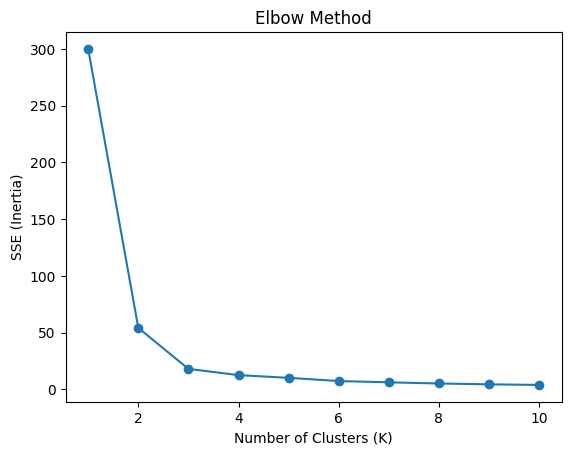

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/iris (1) (1) (1).csv")

X = df[['petal_length', 'petal_width']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sse = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.plot(range(1, 11), sse, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")
plt.show()

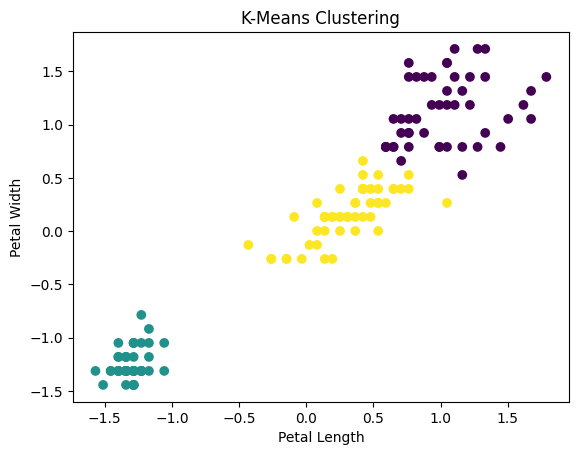

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_pred)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering")
plt.show()

Week 10 - PCA

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/heart (1).csv")

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

print("Before PCA:")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(name, ":", accuracy_score(y_test, y_pred))

Before PCA:
Logistic Regression : 0.8478260869565217
SVM : 0.8641304347826086
Random Forest : 0.8858695652173914


In [ ]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nAfter PCA:")
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    print(name, ":", accuracy_score(y_test, y_pred))


After PCA:
Logistic Regression : 0.8369565217391305
SVM : 0.8804347826086957
Random Forest : 0.842391304347826
